In [1]:
import itertools
import numpy as np

import matplotlib.pyplot as plt
import networkx as nx

import gurobipy as gp
from gurobipy import GRB


# ================================
# Assignment 4 map (Manhattan metric)
# ================================
locations = {
    # Key locations
    "Columbia": (0, 15000),
    "MetMuseum": (1200, 9000),
    "Hotel": (600, 4800),
    "TimesSquare": (600, 3000),
    "GreenwichVillage": (0, 0),

    "Restaurant1": (1700, 4800),
    "Restaurant2": (2000, 0),

    # Grid nodes
    "A": (1200, 15000),
    "B": (1700, 15000),
    "C": (0, 9000),
    "D": (1700, 9000),
    "E": (0, 4800),
    "F": (1200, 4800),
    "G": (0, 3000),
    "H": (1200, 3000),
    "I": (1700, 3000),
    "J": (2000, 3000),
    "K": (1200, 0),
    "L": (1700, 0),
}

base_edges = [
    ("GreenwichVillage", "K"),
    ("K", "L"),
    ("L", "Restaurant2"),
    ("J", "Restaurant2"),
    ("L", "I"),
    ("K", "H"),
    ("GreenwichVillage", "G"),
    ("TimesSquare", "G"),
    ("TimesSquare", "H"),
    ("I", "H"),
    ("I", "J"),
    ("E", "Hotel"),
    ("F", "Hotel"),
    ("F", "Restaurant1"),
    ("I", "Restaurant1"),
    ("H", "F"),
    ("TimesSquare", "Hotel"),
    ("G", "E"),
    ("E", "C"),
    ("F", "MetMuseum"),
    ("Restaurant1", "D"),
    ("D", "MetMuseum"),
    ("MetMuseum", "C"),
    ("C", "Columbia"),
    ("MetMuseum", "A"),
    ("D", "B"),
    ("A", "B"),
    ("A", "Columbia"),
]


def manhattan(u, v):
    (x1, y1), (x2, y2) = locations[u], locations[v]
    return abs(x1 - x2) + abs(y1 - y2)


G_map = nx.Graph()
for node, pos in locations.items():
    G_map.add_node(node, pos=pos)
for u, v in base_edges:
    G_map.add_edge(u, v, weight=manhattan(u, v))


# ================================
# Stops for the one-day plan
# ================================
start = "Hotel"
required_sights = ["GreenwichVillage", "Columbia", "MetMuseum"]
restaurant_options = ["Restaurant1", "Restaurant2"]



[SP brute-force]
- restaurant: Restaurant1
- stop order: ['Hotel', 'GreenwichVillage', 'Restaurant1', 'MetMuseum', 'Columbia']
- total distance: 23800.0
- expanded route nodes: ['Hotel', 'E', 'G', 'GreenwichVillage', 'K', 'H', 'F', 'Restaurant1', 'F', 'MetMuseum', 'C', 'Columbia']


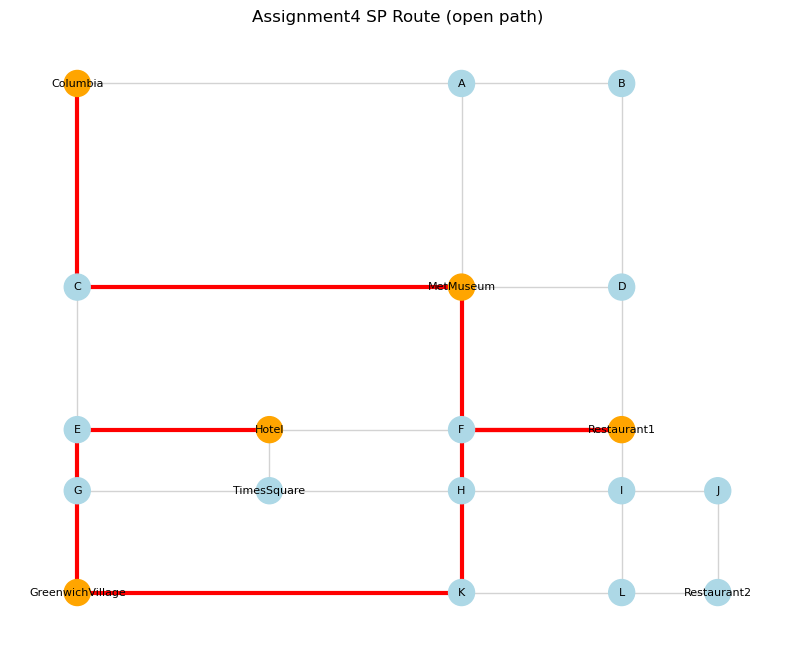

In [2]:
# ================================
# Method 1: SP via brute-force stop order
# Open path: Hotel -> visit all sights + one restaurant (no return to Hotel)
# ================================

best_solution_sp = None

for restaurant in restaurant_options:
    stops_to_visit = required_sights + [restaurant]

    best_rest_dist = None
    best_rest_stop_order = None
    best_rest_route_nodes = None

    for perm in itertools.permutations(stops_to_visit):
        stop_order = [start] + list(perm)  # open path; last stop is perm[-1]

        feasible = True
        total_dist = 0.0
        route_nodes = []

        for a, b in zip(stop_order[:-1], stop_order[1:]):
            try:
                seg_nodes = nx.shortest_path(G_map, source=a, target=b, weight="weight")
                seg_len = nx.shortest_path_length(G_map, source=a, target=b, weight="weight")
            except nx.NetworkXNoPath:
                feasible = False
                break

            total_dist += seg_len
            if not route_nodes:
                route_nodes.extend(seg_nodes)
            else:
                route_nodes.extend(seg_nodes[1:])  # avoid duplicate join node

        if not feasible:
            continue

        if best_rest_dist is None or total_dist < best_rest_dist:
            best_rest_dist = total_dist
            best_rest_stop_order = stop_order
            best_rest_route_nodes = route_nodes

    if best_rest_dist is None:
        continue

    if best_solution_sp is None or best_rest_dist < best_solution_sp["total_distance"]:
        best_solution_sp = {
            "restaurant": restaurant,
            "total_distance": best_rest_dist,
            "stop_order": best_rest_stop_order,
            "route_nodes": best_rest_route_nodes,
        }


if best_solution_sp is None:
    print("SP: no feasible open path found. Check base map connectivity.")
else:
    print("\n[SP brute-force]")
    print("- restaurant:", best_solution_sp["restaurant"])
    print("- stop order:", best_solution_sp["stop_order"])
    print("- total distance:", best_solution_sp["total_distance"])
    print("- expanded route nodes:", best_solution_sp["route_nodes"])

    # Plot
    pos = {n: locations[n] for n in G_map.nodes()}
    route_nodes = best_solution_sp["route_nodes"]
    route_edges = list(zip(route_nodes[:-1], route_nodes[1:]))

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(
        G_map, pos, edgelist=list(G_map.edges()), edge_color="lightgray", width=1
    )
    nx.draw_networkx_edges(
        G_map, pos, edgelist=route_edges, edge_color="red", width=3
    )

    special = set([start] + required_sights + [best_solution_sp["restaurant"]])
    node_colors = ["orange" if n in special else "lightblue" for n in G_map.nodes()]

    nx.draw_networkx_nodes(G_map, pos, node_color=node_colors, node_size=350)
    nx.draw_networkx_labels(G_map, pos, font_size=8)

    plt.title("Assignment4 SP Route (open path)")
    plt.axis("off")
    plt.show()


Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G517)

CPU model: Apple M4 Pro
Thread count: 14 physical cores, 14 logical processors, using up to 14 threads

Optimize a model with 22 rows, 30 columns and 86 nonzeros (Min)
Model fingerprint: 0xc2d41c8c
Model has 20 linear objective coefficients
Variable types: 5 continuous, 25 integer (25 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [1e+03, 2e+04]
  Bounds range     [1e+00, 4e+00]
  RHS range        [1e+00, 3e+00]

Found heuristic solution: objective 41800.000000
Presolve removed 0 rows and 6 columns
Presolve time: 0.00s
Presolved: 22 rows, 24 columns, 100 nonzeros
Variable types: 4 continuous, 20 integer (20 binary)

Root relaxation: objective 3.100000e+04, 17 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  

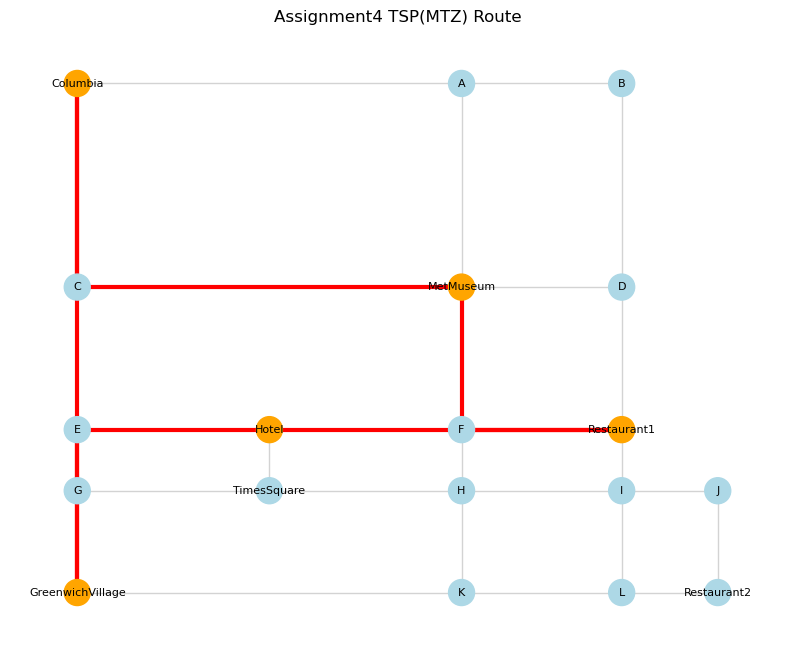

In [3]:
# ================================
# Method 2: TSP (MTZ) on metric closure
# Hotel -> 3 sights -> (one restaurant) -> Hotel
# ================================

best_solution_tsp = None


def extract_cycle_from_x(x_vars, n, start_idx=0, threshold=0.5):
    """Extract Hamiltonian cycle indices from the binary arc variables."""
    current = start_idx
    cycle = [current]
    while True:
        nxt = None
        for j in range(n):
            if x_vars[current, j].X > threshold:
                nxt = j
                break
        if nxt is None:
            raise RuntimeError("Failed to extract cycle: no outgoing arc found.")
        current = nxt
        cycle.append(current)
        if current == start_idx:
            break
    return cycle


for restaurant in restaurant_options:
    stops = [start] + required_sights + [restaurant]  # all stops to be visited
    n = len(stops)

    # metric closure distances between stops
    Distance = [[0 for _ in range(n)] for _ in range(n)]
    path_nodes = {}

    feasible = True
    for i in range(n):
        for j in range(n):
            if i == j:
                Distance[i][j] = 0
                continue
            s, t = stops[i], stops[j]
            try:
                Distance[i][j] = nx.shortest_path_length(G_map, source=s, target=t, weight="weight")
                path_nodes[(i, j)] = nx.shortest_path(G_map, source=s, target=t, weight="weight")
            except nx.NetworkXNoPath:
                feasible = False
                break
        if not feasible:
            break

    if not feasible:
        continue

    # MTZ TSP model on the complete directed graph of stops
    m = gp.Model("A4_TSP_MTZ")

    x = {}
    for i in range(n):
        for j in range(n):
            x[i, j] = m.addVar(vtype=GRB.BINARY, obj=Distance[i][j], name=f"x({i})({j})")
    m.update()

    u = {}
    for i in range(n):
        if i > 0:
            u[i] = m.addVar(vtype=GRB.CONTINUOUS, lb=1.0, ub=n - 1, obj=0.0, name=f"u({i})")
        else:
            # Fix u[0] = 0
            u[i] = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, ub=0.0, obj=0.0, name=f"u({i})")
    m.update()

    # Each node has exactly one incoming arc
    for j in range(n):
        m.addConstr(gp.quicksum(x[i, j] for i in range(n)) == 1, name=f"in_{j}")

    # Each node has exactly one outgoing arc
    for i in range(n):
        m.addConstr(gp.quicksum(x[i, j] for j in range(n)) == 1, name=f"out_{i}")
        x[i, i].ub = 0  # forbid self-loops

    # MTZ subtour elimination constraints
    for i in range(n - 1):
        for j in range(n - 1):
            if i != j:
                m.addConstr(
                    u[j + 1] >= u[i + 1] + 1 - (n - 1) * (1 - x[i + 1, j + 1])
                )

    m.modelSense = GRB.MINIMIZE
    m.update()
    m.optimize()

    if m.Status != GRB.OPTIMAL:
        continue

    stop_cycle = extract_cycle_from_x(x, n, start_idx=0)
    total_dist_metric = sum(Distance[a][b] for a, b in zip(stop_cycle[:-1], stop_cycle[1:]))

    # Expand stop-cycle to base-map node route
    route_nodes = []
    for a_idx, b_idx in zip(stop_cycle[:-1], stop_cycle[1:]):
        seg_nodes = path_nodes[(a_idx, b_idx)]
        if not route_nodes:
            route_nodes.extend(seg_nodes)
        else:
            route_nodes.extend(seg_nodes[1:])

    sol = {
        "restaurant": restaurant,
        "total_distance": total_dist_metric,
        "stop_cycle": [stops[i] for i in stop_cycle],
        "route_nodes": route_nodes,
    }

    if best_solution_tsp is None or sol["total_distance"] < best_solution_tsp["total_distance"]:
        best_solution_tsp = sol


if best_solution_tsp is None:
    print("TSP(MTZ): no feasible solution found. Check base map connectivity.")
else:
    print("\n[TSP MTZ]")
    print("- restaurant:", best_solution_tsp["restaurant"])
    print("- stop cycle:", best_solution_tsp["stop_cycle"])
    print("- total distance:", best_solution_tsp["total_distance"])
    print("- expanded route nodes:", best_solution_tsp["route_nodes"])

    # Plot
    pos = {n: locations[n] for n in G_map.nodes()}
    route_nodes = best_solution_tsp["route_nodes"]
    route_edges = list(zip(route_nodes[:-1], route_nodes[1:]))

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_edges(G_map, pos, edgelist=list(G_map.edges()), edge_color="lightgray", width=1)
    nx.draw_networkx_edges(G_map, pos, edgelist=route_edges, edge_color="red", width=3)

    special = set([start] + required_sights + [best_solution_tsp["restaurant"]])
    node_colors = ["orange" if n in special else "lightblue" for n in G_map.nodes()]

    nx.draw_networkx_nodes(G_map, pos, node_color=node_colors, node_size=350)
    nx.draw_networkx_labels(G_map, pos, font_size=8)

    plt.title("Assignment4 TSP(MTZ) Route")
    plt.axis("off")
    plt.show()
